In [4]:
import pandas as pd

df = pd.read_csv("avocado_ripeness_dataset.csv")
df

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking
...,...,...,...,...,...,...,...,...,...
245,94.1,83,80,58,dark green,72,254,134,hard
246,21.6,17,36,19,black,47,182,240,firm-ripe
247,14.0,4,40,17,black,37,188,274,ripe
248,61.5,63,87,75,green,65,261,162,pre-conditioned


In [5]:
df.shape

(250, 9)

In [6]:
df.columns

Index(['firmness', 'hue', 'saturation', 'brightness', 'color_category',
       'sound_db', 'weight_g', 'size_cm3', 'ripeness'],
      dtype='object')

In [7]:
df.dtypes

firmness          float64
hue                 int64
saturation          int64
brightness          int64
color_category     object
sound_db            int64
weight_g            int64
size_cm3            int64
ripeness           object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firmness        250 non-null    float64
 1   hue             250 non-null    int64  
 2   saturation      250 non-null    int64  
 3   brightness      250 non-null    int64  
 4   color_category  250 non-null    object 
 5   sound_db        250 non-null    int64  
 6   weight_g        250 non-null    int64  
 7   size_cm3        250 non-null    int64  
 8   ripeness        250 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 17.7+ KB


In [9]:
df.describe()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3
count,250.000000,250.00000,250.000000,250.00000,250.000000,250.000000,250.000000
mean,50.618400,125.94400,64.356000,45.07200,58.016000,220.188000,208.644000
std,27.277678,117.13767,17.377144,19.11629,13.838126,34.405225,55.940564
min,10.300000,1.00000,30.000000,10.00000,30.000000,152.000000,100.000000
25%,25.750000,25.25000,51.250000,31.00000,47.250000,193.250000,155.250000
50%,48.950000,77.00000,65.000000,46.00000,60.000000,220.000000,218.000000
75%,74.050000,278.75000,76.750000,58.00000,68.000000,245.000000,260.500000
max,98.800000,329.00000,99.000000,78.00000,79.000000,299.000000,299.000000


In [10]:
df["color_category"].value_counts()

color_category
black         75
purple        75
green         50
dark green    50
Name: count, dtype: int64

In [11]:
df["ripeness"].value_counts()

ripeness
ripe               50
pre-conditioned    50
hard               50
breaking           50
firm-ripe          50
Name: count, dtype: int64

In [12]:
df.head()

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking


In [13]:
df.tail()

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
245,94.1,83,80,58,dark green,72,254,134,hard
246,21.6,17,36,19,black,47,182,240,firm-ripe
247,14.0,4,40,17,black,37,188,274,ripe
248,61.5,63,87,75,green,65,261,162,pre-conditioned
249,17.8,27,30,36,black,40,190,272,ripe


In [14]:
df.sample(5)

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
89,97.7,71,74,44,dark green,74,228,140,hard
164,70.4,49,62,72,green,68,274,157,pre-conditioned
185,22.2,21,41,33,black,55,189,275,firm-ripe
121,64.6,66,82,71,green,69,237,177,pre-conditioned
149,16.8,3,31,23,black,31,161,298,ripe


In [15]:
df.isna().sum()

firmness          0
hue               0
saturation        0
brightness        0
color_category    0
sound_db          0
weight_g          0
size_cm3          0
ripeness          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

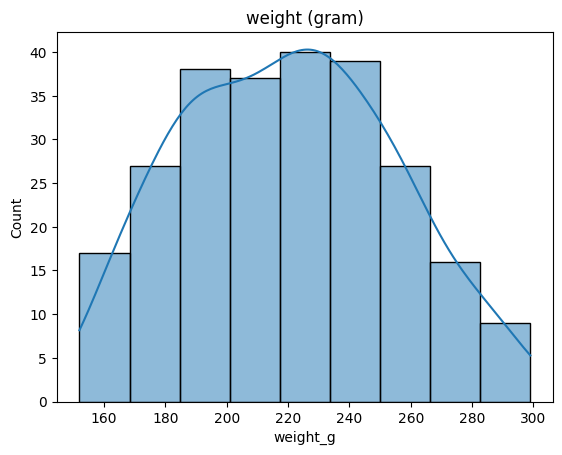

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["weight_g"], kde=True)
plt.title("weight (gram)")
plt.show()

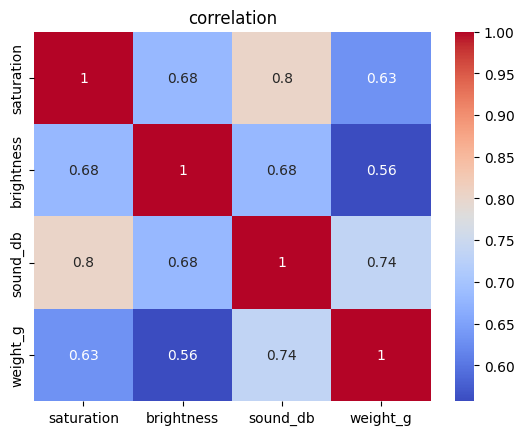

In [18]:
num_features=df[["saturation", "brightness", "sound_db", "weight_g"]] 

corr=num_features.corr() 

sns.heatmap(corr, annot=True, cmap="coolwarm") 
plt.title("correlation") 
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["firmness","hue","saturation","brightness","color_category","sound_db","weight_g","size_cm3"]]
y = df["ripeness"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["firmness", "hue", "saturation", "brightness","sound_db","weight_g","size_cm3"]
ordinal_columns = ["color_category"]

warna_order = ["green","dark green","purple", "black"]
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  1.0
Classification Report :
                  precision    recall  f1-score   support

       breaking       1.00      1.00      1.00        13
      firm-ripe       1.00      1.00      1.00         9
           hard       1.00      1.00      1.00         8
pre-conditioned       1.00      1.00      1.00         7
           ripe       1.00      1.00      1.00        13

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50

Confusion Matrix :
 [[13  0  0  0  0]
 [ 0  9  0  0  0]
 [ 0  0  8  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0 13]]


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["firmness","hue","saturation","brightness","color_category","sound_db","weight_g","size_cm3"]]
y = df["ripeness"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["firmness", "hue", "saturation", "brightness","sound_db","weight_g","size_cm3"]
ordinal_columns = ["color_category"]

warna_order = ["green","dark green","purple", "black"]
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model_forest = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model_forest", RandomForestClassifier())
    ]
)

model_forest.fit(X_train, y_train)
y_pred = model_forest.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  1.0
Classification Report :
                  precision    recall  f1-score   support

       breaking       1.00      1.00      1.00        13
      firm-ripe       1.00      1.00      1.00         9
           hard       1.00      1.00      1.00         8
pre-conditioned       1.00      1.00      1.00         7
           ripe       1.00      1.00      1.00        13

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50

Confusion Matrix :
 [[13  0  0  0  0]
 [ 0  9  0  0  0]
 [ 0  0  8  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0 13]]


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["firmness","hue","saturation","brightness","color_category","sound_db","weight_g","size_cm3"]]
y = df["ripeness"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["firmness", "hue", "saturation", "brightness","sound_db","weight_g","size_cm3"]
ordinal_columns = ["color_category"]

warna_order = ["green","dark green","purple", "black"]
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model_tree = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("modeltree", DecisionTreeClassifier())
    ]
)

model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  1.0
Classification Report :
                  precision    recall  f1-score   support

       breaking       1.00      1.00      1.00        13
      firm-ripe       1.00      1.00      1.00         9
           hard       1.00      1.00      1.00         8
pre-conditioned       1.00      1.00      1.00         7
           ripe       1.00      1.00      1.00        13

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50

Confusion Matrix :
 [[13  0  0  0  0]
 [ 0  9  0  0  0]
 [ 0  0  8  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0 13]]


In [22]:
data_baru = pd.DataFrame([[93.8,105,87,41,"dark green",75,299,140]], 
                         columns=["firmness","hue","saturation","brightness","color_category","sound_db","weight_g","size_cm3"])

prediksi = model_tree.predict(data_baru)[0]
print(f"model memprediksi Kematangan Alpukat {prediksi}")

model memprediksi Kematangan Alpukat hard


In [23]:
import joblib

joblib.dump(model_tree,"model_tree.joblib")

['model_tree.joblib']